In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [50]:
 # load  data
df = pd.read_csv('../../data/raw/train.csv')
df

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,97075632,1,0.000000,1,51.295195,0.000000,0.000000,0.000000,3.956904,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,17,6,6,66.340624,0
217,97362560,2,1.127102,0,1.176991,0.000000,0.000000,0.000000,0.777943,0.000000,...,0.000000,-0.277779,0.277779,-0.000000,-0.000000,18,1,7,5.694898,1
218,97805715,2,3.710653,0,71.946930,0.000000,0.000000,0.000000,4.289732,0.000000,...,0.000000,0.694609,0.694609,0.000000,0.000000,18,1,9,44.011253,0
219,99071478,1,0.000000,1,20.223659,0.000000,0.000000,0.000000,3.055117,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,15,0,8,22.975783,1


In [51]:
# Looking Target Columns
target = ['time_to_hit_hours',
          'event']
df[target].head()

,time_to_hit_hours,event
0,18.892512,0
1,22.048108,1
2,0.888895,1
3,60.953021,0
4,44.990274,0


# Event Distribution Chart

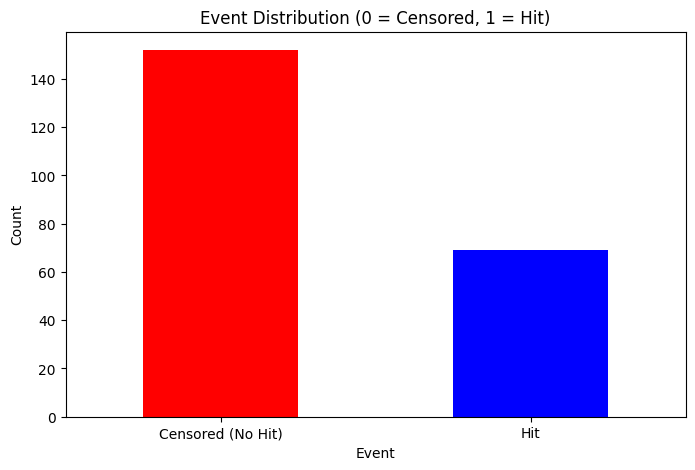

Hit fires: 31.2%
Censored fires: 68.8%


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Event distribution
plt.figure(figsize=(8, 5))
df['event'].value_counts().plot(kind='bar', color=['red', 'blue'])
plt.title('Event Distribution (0 = Censored, 1 = Hit)')
plt.xlabel('Event')
plt.ylabel('Count')
plt.xticks([0, 1], ['Censored (No Hit)', 'Hit'], rotation=0)
plt.show()

# Percentage
hit_pct = df['event'].mean() * 100
print(f"Hit fires: {hit_pct:.1f}%")
print(f"Censored fires: {100-hit_pct:.1f}%")

# Time hit hours

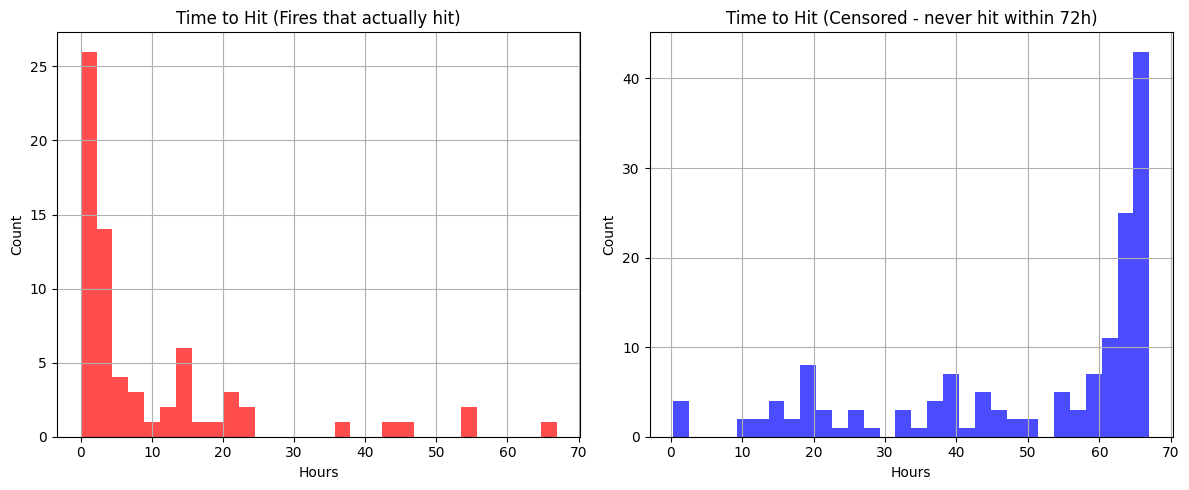

In [53]:
# Yeh batata hai ki fire kitne ghante mein village tak pahunchi, ya kitni der tak monitor ki gayi


# Time distribution for hit fires
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df[df['event']==1]['time_to_hit_hours'].hist(bins=30, color='red', alpha=0.7)
plt.title('Time to Hit (Fires that actually hit)')
plt.xlabel('Hours')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df[df['event']==0]['time_to_hit_hours'].hist(bins=30, color='blue', alpha=0.7)
plt.title('Time to Hit (Censored - never hit within 72h)')
plt.xlabel('Hours')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

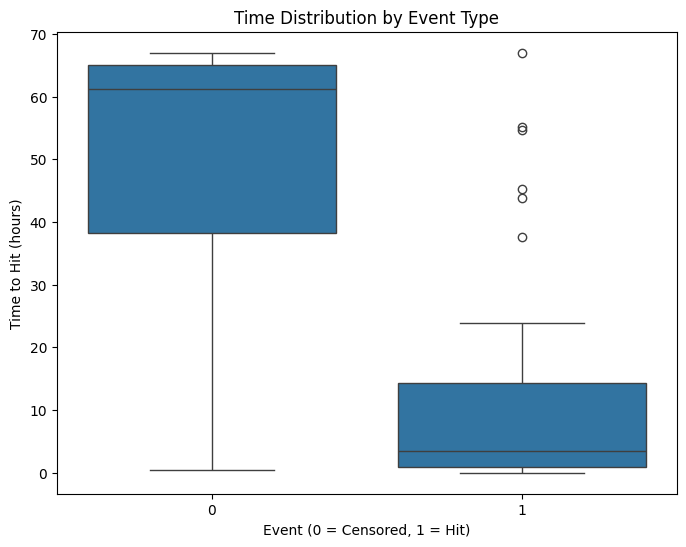

In [54]:
# box plot of time_to_hit_hours by event
plt.figure(figsize=(8, 6))
sns.boxplot(x='event', y='time_to_hit_hours', data=df)
plt.title('Time Distribution by Event Type')
plt.xlabel('Event (0 = Censored, 1 = Hit)')
plt.ylabel('Time to Hit (hours)')
plt.show()

EVENT = 1 (Hit Fires) - Outlier Analysis
Total hit fires: 69
Outliers found: 6
Lower bound: -19.26 hours
Upper bound: 34.48 hours
Range without outliers: [-19.26, 34.48]

Outlier values:
     event_id  time_to_hit_hours
9    15743535          54.638109
32   22620173          37.616711
81   42731036          66.920463
108  52259907          43.846683
136  63182365          45.336063
143  66725353          55.170610

EVENT = 0 (Censored Fires) - Outlier Analysis
Total censored fires: 152
Outliers found: 0
Lower bound: -2.23 hours
Upper bound: 105.52 hours
Range without outliers: [-2.23, 105.52]
 No outliers in censored fires!


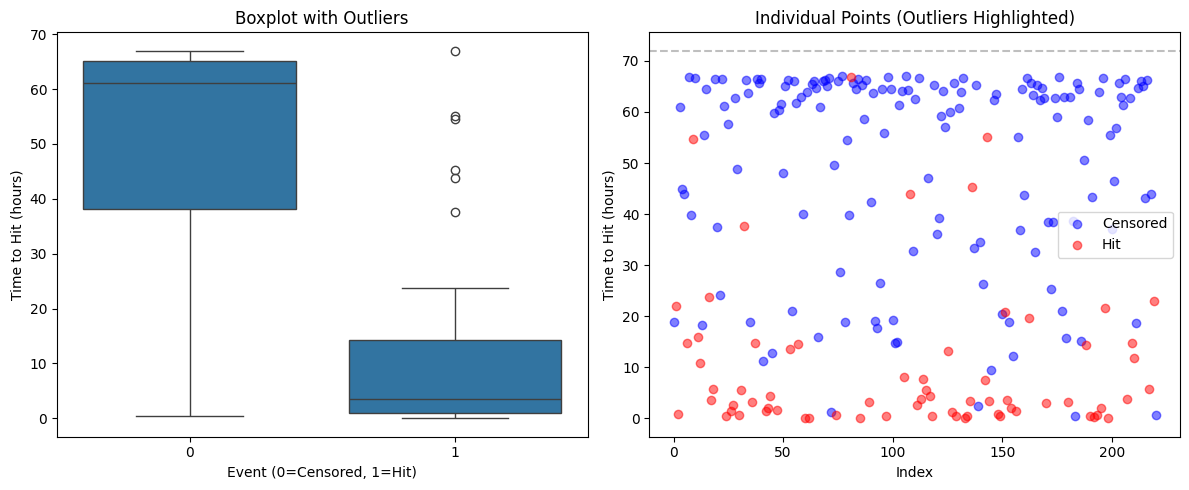


STATISTICAL SUMMARY

Event=1 (Hit Fires):
count    69.000000
mean      9.969870
std      14.528462
min       0.001220
25%       0.888895
50%       3.534846
75%      14.323375
max      66.920463
Name: time_to_hit_hours, dtype: float64

Event=0 (Censored Fires):
count    152.000000
mean      50.095555
std       19.402121
min        0.374486
25%       38.175209
50%       61.168905
75%       65.113659
max       66.994474
Name: time_to_hit_hours, dtype: float64


In [55]:


# Function to find outliers using IQR method
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Event=1 ke liye outliers
hit_fires = df[df['event'] == 1]
hit_outliers, hit_lower, hit_upper = find_outliers_iqr(hit_fires, 'time_to_hit_hours')

print("="*60)
print("EVENT = 1 (Hit Fires) - Outlier Analysis")
print("="*60)
print(f"Total hit fires: {len(hit_fires)}")
print(f"Outliers found: {len(hit_outliers)}")
print(f"Lower bound: {hit_lower:.2f} hours")
print(f"Upper bound: {hit_upper:.2f} hours")
print(f"Range without outliers: [{hit_lower:.2f}, {hit_upper:.2f}]")

if len(hit_outliers) > 0:
    print("\nOutlier values:")
    print(hit_outliers[['event_id', 'time_to_hit_hours']])
else:
    print(" No outliers in hit fires!")

print("\n" + "="*60)
print("EVENT = 0 (Censored Fires) - Outlier Analysis")
print("="*60)

# Event=0 ke liye outliers
censored_fires = df[df['event'] == 0]
censored_outliers, censored_lower, censored_upper = find_outliers_iqr(censored_fires, 'time_to_hit_hours')

print(f"Total censored fires: {len(censored_fires)}")
print(f"Outliers found: {len(censored_outliers)}")
print(f"Lower bound: {censored_lower:.2f} hours")
print(f"Upper bound: {censored_upper:.2f} hours")
print(f"Range without outliers: [{censored_lower:.2f}, {censored_upper:.2f}]")

if len(censored_outliers) > 0:
    print("\nOutlier values:")
    print(censored_outliers[['event_id', 'time_to_hit_hours']])
else:
    print(" No outliers in censored fires!")

# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot with outliers highlighted
sns.boxplot(x='event', y='time_to_hit_hours', data=df, ax=axes[0])
axes[0].set_title('Boxplot with Outliers')
axes[0].set_xlabel('Event (0=Censored, 1=Hit)')
axes[0].set_ylabel('Time to Hit (hours)')

# Scatter plot to see individual points
axes[1].scatter(df[df['event']==0].index, df[df['event']==0]['time_to_hit_hours'], 
                alpha=0.5, label='Censored', color='blue')
axes[1].scatter(df[df['event']==1].index, df[df['event']==1]['time_to_hit_hours'], 
                alpha=0.5, label='Hit', color='red')

# Highlight outliers
if len(censored_outliers) > 0:
    axes[1].scatter(censored_outliers.index, censored_outliers['time_to_hit_hours'], 
                    color='orange', s=100, marker='o', label='Censored Outliers')

axes[1].set_xlabel('Index')
axes[1].set_ylabel('Time to Hit (hours)')
axes[1].set_title('Individual Points (Outliers Highlighted)')
axes[1].legend()
axes[1].axhline(y=72, color='gray', linestyle='--', alpha=0.5, label='72h limit')

plt.tight_layout()
plt.show()

# Statistical summary
print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print("\nEvent=1 (Hit Fires):")
print(hit_fires['time_to_hit_hours'].describe())

print("\nEvent=0 (Censored Fires):")
print(censored_fires['time_to_hit_hours'].describe())

# Key Insights from Boxplot Analysis

## 1. Two Distinct Fire Behaviors
- **Hit Fires (Event=1)**: Mostly **fast** (0-15 hours)
- **Censored Fires (Event=0)**: Mostly **slow** (38-65 hours)
- → Model can easily separate urgent vs non-urgent fires

## 2. Late Hits Are Rare but Real
- Only **6 out of 69 hit fires** (8.7%) occur after 34 hours
- These are **true outliers** - not data errors
- → Model should learn: "most hit early, but late hit possible"

## 3. Censored Data Is Clean
- No outliers in censored fires
- All values between 0-67 hours (within 72h limit)
- → Monitoring was consistent across all fires

## 4. Why This Matters for Modeling
- **Urgency ranking**: Early vs late hits are clearly separated
- **Probability calibration**: Model can assign low probabilities to late hours
- **Real-world use**: Matches actual fire behavior (most hit fast, some slow)



# Cumulative Distribution Function (CDF) - Real Analysis

12h: 71.0% fires hit within 12 hours
24h: 91.3% fires hit within 24 hours
48h: 95.7% fires hit within 48 hours
72h: 100.0% fires hit within 72 hours


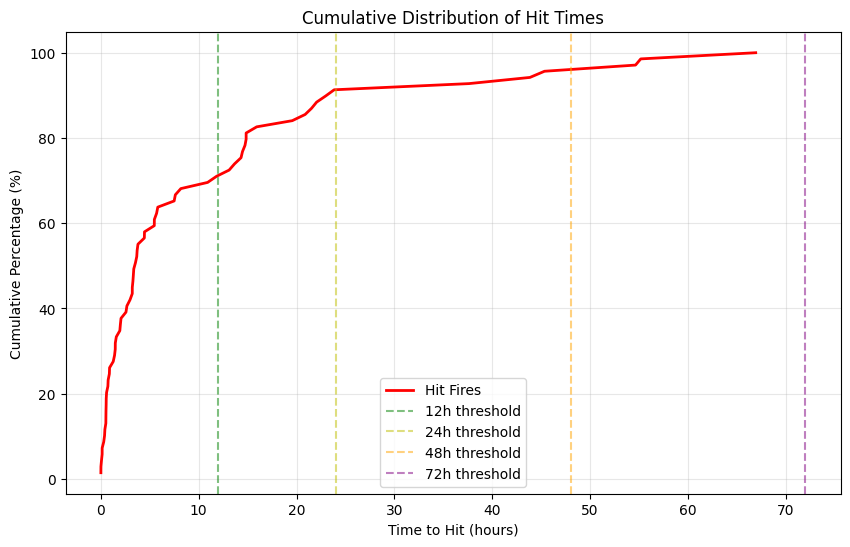

In [56]:
# CDF
plt.figure(figsize=(10, 6))

# For hit fires
hit_times = df[df['event']==1]['time_to_hit_hours'].sort_values()
cumulative = np.arange(1, len(hit_times)+1) / len(hit_times) * 100
plt.plot(hit_times, cumulative, 'r-', linewidth=2, label='Hit Fires')

# Add reference lines for 12h, 24h, 48h, 72h
for h, color in zip([12, 24, 48, 72], ['g', 'y', 'orange', 'purple']):
    plt.axvline(x=h, color=color, linestyle='--', alpha=0.5, label=f'{h}h threshold')
    pct = (hit_times <= h).mean() * 100
    print(f"{h}h: {pct:.1f}% fires hit within {h} hours")

plt.title('Cumulative Distribution of Hit Times')
plt.xlabel('Time to Hit (hours)')
plt.ylabel('Cumulative Percentage (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [57]:
# Exact CDF values 
hit_times = df[df['event']==1]['time_to_hit_hours'].sort_values()
cdf_values = np.arange(1, len(hit_times)+1) / len(hit_times) * 100

# Specific times par values dekho
for t in [12, 24, 48, 72]:
    pct = (hit_times <= t).mean() * 100
    print(f"{t}h: {pct:.1f}% fires hit within {t} hours")

12h: 71.0% fires hit within 12 hours
24h: 91.3% fires hit within 24 hours
48h: 95.7% fires hit within 48 hours
72h: 100.0% fires hit within 72 hours


# Cumulative Distribution Function (CDF) - Explained

## What is CDF?
CDF shows **"what percentage of fires have hit by a specific time"**

## Your Data:
| Time | Fires Hit | Meaning |
|------|-----------|---------|
| 12h | 71.0% | 71% fires hit within 12 hours |
| 24h | 91.3% | 91% fires hit within 24 hours |
| 48h | 95.7% | 96% fires hit within 48 hours |
| 72h | 100.0% | All fires hit by 72 hours |

## Key Insights:
1. **Most fires hit early** (71% in first 12h)
2. **Almost all fires hit by 24h** (91%)
3. **Very few fires hit after 24h** (only 9%)
4. **48-72h window** has only ~4% fires

## Why 48h has 40% weight?
Not because many fires hit then, but because:
- It's the **best time for action**
- Enough time to plan evacuation
- Not too far in future (uncertainty low)

`Hindi`<br>
CDF bas yeh batata hai: "X time tak kitni percentage fires hit ho chuki hain"




# Temporal Coverage Features

In [58]:
temporal_coverage = ['num_perimeters_0_5h',
                     'dt_first_last_0_5h',
                     'low_temporal_resolution_0_5h'

]

df[temporal_coverage].sample(5)

,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h
58,1,0.0,1
65,1,0.0,1
220,1,0.0,1
28,1,0.0,1
91,1,0.0,1


In [59]:
df[temporal_coverage].describe()

,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h
count,221.000000,221.000000,221.000000
mean,2.063348,0.979869,0.728507
std,2.578859,1.738052,0.445739
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000
75%,2.000000,1.356107,1.000000
max,17.000000,4.994457,1.000000


In [60]:
for i in temporal_coverage:
    print(f"\nDistribution of {i}:")
    print(df[i].value_counts())



Distribution of num_perimeters_0_5h:
num_perimeters_0_5h
1     160
2      25
3       7
7       7
4       5
12      5
5       5
9       2
6       2
11      1
13      1
17      1
Name: count, dtype: int64

Distribution of dt_first_last_0_5h:
dt_first_last_0_5h
0.000000    160
4.265188      1
1.169918      1
4.777526      1
4.975273      1
           ... 
0.911586      1
4.111125      1
4.921366      1
1.127102      1
3.710653      1
Name: count, Length: 62, dtype: int64

Distribution of low_temporal_resolution_0_5h:
low_temporal_resolution_0_5h
1    161
0     60
Name: count, dtype: int64


#  Temporal Coverage Analysis

## 1. num_perimeters_0_5h (How many measurements?)
| Value | Count | % | Quality |
|-------|-------|-----|---------|
| 1 | 160 | 72.4% |  Poor |
| 2 | 25 | 11.3% |  Medium |
| 3-17 | 36 | 16.3% |  Good |

**Key insight:** 72% fires measured only once

---

## 2. dt_first_last_0_5h (Tracking duration)
| Value | Count | % | Meaning |
|-------|-------|-----|---------|
| 0.0 | 160 | 72.4% | Single measurement  |
| >0 | 61 | 27.6% | Multiple measurements  |

**Key insight:** Only 27% fires tracked over time

---

## 3. low_temporal_resolution_0_5h (Quality flag)
| Value | Count | % | Quality |
|-------|-------|-----|---------|
| 1 | 161 | 72.9% |  Bad data |
| 0 | 60 | 27.1% |  Good data |

**Key insight:** 73% of all fires have poor quality data

---

##  Summary
- **73% fires** = Low quality (1 measurement only)
- **27% fires** = High quality (multiple measurements)



`Hindi`<br>
**1 num_perimeters_0_5h (Kitni baar measure kiya?)**<br>
Problem: 72% fires sirf 1 baar measure hui!<br>
Good: Sirf ~28% fires ko 2+ baar measure kiya<br>

**2 dt_first_last_0_5h (Kitni der tak measure kiya?)**<br>
Problem: 160 fires (72%) ka dt = 0<br>
Good: Sirf 61 fires (28%) ka dt > 0<br>
Inko multiple times measure kiya<br>


**3 low_temporal_resolution_0_5h (Quality flag)**<br>
73% fires = LOW QUALITY data

27% fires = HIGH QUALITY data


 `73% fires (161/221) = Low resolution` <br>
 ` 27% fires (60/221) = High resolution`<br>
**Ye 3 features ek hi baat bata rahe hain - data quality**<br>
**1. High Quality Fires (60 fires):**<br>
   Multiple measurements (2-17 times)<br>
   Tracked for >0.5 hours<br>
   Reliable growth patterns

**2. Low Quality Fires (161 fires):**<br>
   Sirf 1 measurement<br>
   No growth data<br>
   Unreliable for detailed analysis





In [61]:
df.query('num_perimeters_0_5h > 1 and dt_first_last_0_5h > 0 and low_temporal_resolution_0_5h == 1')

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
53,31560147,2,0.338525,1,0.34664,0.0,0.0,0.0,0.297613,0.0,...,0.0,0.003611,0.003611,-0.0,0.0,20,0,6,13.656787,1


In [62]:
df_clean = df.copy()
# Or bhi edge cases ho sakte hain
df_clean['edge_case'] = (
    ((df_clean['num_perimeters_0_5h'] == 1) & (df_clean['area_growth_abs_0_5h'] > 0)) |  # single perimeter but growth
    ((df_clean['num_perimeters_0_5h'] > 1) & (df_clean['dt_first_last_0_5h'] < 0.5) & (df_clean['area_growth_abs_0_5h'] == 0))  # your case
).astype(int)

In [63]:
df_clean['edge_case'].value_counts()

edge_case
0    220
1      1
Name: count, dtype: int64

In [67]:
df_clean['track_quality'] = 0  # default
df_clean.loc[(df_clean['num_perimeters_0_5h'] == 1), 'track_quality'] = 1  # single perimeter
df_clean.loc[(df_clean['num_perimeters_0_5h'] > 1) & (df_clean['dt_first_last_0_5h'] < 0.5), 'track_quality'] = 2  # short multiple
df_clean.loc[(df_clean['num_perimeters_0_5h'] > 1) & (df_clean['dt_first_last_0_5h'] >= 0.5), 'track_quality'] = 3  # good quality

df_clean['track_quality'] = df_clean['track_quality'].replace({2: 3})

In [68]:
df_clean['track_quality'].value_counts()

track_quality
1    160
3     61
Name: count, dtype: int64

# Growth Features

In [69]:
growth =['area_first_ha',
         'area_growth_abs_0_5h',
         'area_growth_rel_0_5h',
         'area_growth_rate_ha_per_h',
         'radial_growth_m',
         'radial_growth_rate_m_per_h'


]
df[growth].sample(5)

,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,radial_growth_m,radial_growth_rate_m_per_h
202,9082.076151,0.000000,0.000000,0.000000,0.000000,0.000000
11,117.219890,0.000000,0.000000,0.000000,0.000000,0.000000
0,79.696304,2.875935,0.036086,0.674281,9.007182,2.111790
113,39.334108,130.775790,3.324743,29.066990,382.008678,84.907477
106,296.995716,0.000000,0.000000,0.000000,0.000000,0.000000


In [81]:
df['area_first_ha'].describe()

count      221.000000
mean       619.131641
std       1447.723668
min          0.037525
25%         25.219058
50%        110.149250
75%        485.092561
max      11942.392115
Name: area_first_ha, dtype: float64

In [82]:
import pandas as pd
import numpy as np

# Growth features list
growth = ['area_first_ha',
          'area_growth_abs_0_5h',
          'area_growth_rel_0_5h',
          'area_growth_rate_ha_per_h',
          'radial_growth_m',
          'radial_growth_rate_m_per_h']

# Calculate mean of area_first_ha
mean_area = df['area_first_ha'].mean()
print(f"Mean area_first_ha: {mean_area:.2f} hectares\n")

# Filter rows where area_first_ha > mean
large_fires = df[df['area_first_ha'] > mean_area]

# Show results
print(f"Fires with area > mean: {len(large_fires)} out of {len(df)}")
print(f"Percentage: {len(large_fires)/len(df)*100:.1f}%\n")

# Display growth features for these fires
print(large_fires[growth].head(10))

Mean area_first_ha: 619.13 hectares

Fires with area > mean: 49 out of 221
Percentage: 22.2%

    area_first_ha  area_growth_abs_0_5h  area_growth_rel_0_5h  \
7     1388.283778                   0.0                   0.0   
10     634.480139                   0.0                   0.0   
15    1749.278716                   0.0                   0.0   
19    3638.729983                   0.0                   0.0   
20    1255.878023                   0.0                   0.0   
29    2300.009048                   0.0                   0.0   
34    3316.037397                   0.0                   0.0   
36     845.113964                   0.0                   0.0   
39    3434.827782                   0.0                   0.0   
44    1682.296667                   0.0                   0.0   

    area_growth_rate_ha_per_h  radial_growth_m  radial_growth_rate_m_per_h  
7                         0.0              0.0                         0.0  
10                        0.0       

In [83]:
# Large fires ka event dekho
large_fires = df[df['area_first_ha'] > 619.13]
hit_rate_large = large_fires['event'].mean() * 100
print(f"Large fires hit rate: {hit_rate_large:.1f}%")

# Small fires ka event dekho
small_fires = df[df['area_first_ha'] <= 619.13]
hit_rate_small = small_fires['event'].mean() * 100
print(f"Small fires hit rate: {hit_rate_small:.1f}%")

Large fires hit rate: 12.2%
Small fires hit rate: 36.6%


In [ ]:
# Growing fires ke event dekho
growing = df[df['area_growth_abs_0_5h'] > 0]
print(f"Growing fires: {len(growing)}")
print(f"Hit rate: {growing['event'].mean()*100:.1f}%")

# Non-growing fires
non_growing = df[df['area_growth_abs_0_5h'] == 0]
print(f"Non-growing fires: {len(non_growing)}")
print(f"Hit rate: {non_growing['event'].mean()*100:.1f}%")

# # Create binary growth flag
# df['had_growth'] = (df['area_growth_abs_0_5h'] > 0).astype(int)

Growing fires: 24
Hit rate: 70.8%
Non-growing fires: 196
Hit rate: 26.0%


In [ ]:
# Create new dataframe for growth analysis
df_growth = df.copy()

# 1. Growth flag
df_growth['had_growth'] = (df_growth['area_growth_abs_0_5h'] > 0).astype(int)

# 2. Size flag (using your mean value)
mean_area = 619.13
df_growth['is_large'] = (df_growth['area_first_ha'] > mean_area).astype(int)

# 3. Interaction feature (MOST POWERFUL)
df_growth['risk_category'] = 0  # default
df_growth.loc[(df_growth['is_large']==0) & (df_growth['had_growth']==0), 'risk_category'] = 1  # small no growth
df_growth.loc[(df_growth['is_large']==0) & (df_growth['had_growth']==1), 'risk_category'] = 2  # small growing 
df_growth.loc[(df_growth['is_large']==1), 'risk_category'] = 3  # large

# Check results
print("="*50)
print("RISK CATEGORY ANALYSIS")
print("="*50)
print("\nCount by category:")
print(df_growth['risk_category'].value_counts().sort_index())

print("\nHit rate by category:")
print(df_growth.groupby('risk_category')['event'].mean().round(3) * 100)

print("\nDetailed breakdown:")
print(df_growth.groupby('risk_category').agg({
    'event': ['count', 'mean'],
    'area_first_ha': 'mean',
    'had_growth': 'mean'
}).round(3))

RISK CATEGORY ANALYSIS

Count by category:
risk_category
1    150
2     22
3     49
Name: count, dtype: int64

Hit rate by category:
risk_category
1    32.0
2    68.2
3    12.2
Name: event, dtype: float64

Detailed breakdown:
              event        area_first_ha had_growth
              count   mean          mean       mean
risk_category                                      
1               150  0.320       125.458      0.000
2                22  0.682       109.223      1.000
3                49  0.122      2359.315      0.041


In [86]:
features = ['risk_category', 'had_growth', 'is_large']
df_growth[features].value_counts()

risk_category  had_growth  is_large
1              0           0           150
3              0           1            47
2              1           0            22
3              1           1             2
Name: count, dtype: int64

In [87]:
df_growth['risk_category']

0      2
1      1
2      1
3      1
4      1
      ..
216    1
217    1
218    1
219    1
220    3
Name: risk_category, Length: 221, dtype: int64

 Use Option A - just risk_category<br>
 One feature, 3 categories, perfect separation<br>
final_features = ['risk_category']<br>
Matlab: risk_category already sari information de raha <br>hai jo had_growth aur is_large dete hain.